In [1]:
# --- parameters (patch_notebook_params.py) ---
MAX_EPOCHS = 2000
N_SAMPLES = 10           # run_metrics.py forces 50 for generative methods
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "results/metrics.csv"


In [2]:
# Parameters
MAX_EPOCHS = 2000
N_SAMPLES = 1
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "/Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/GP/4dvarnet_lstm_metrics_train.csv"
SOLVER_TYPE = "lstm"


In [3]:
# --- epoch heartbeat (patch_notebook_params.py) ---
import pytorch_lightning as _pl

class EpochHeartbeat(_pl.Callback):
    """Prints one clear progress line every `every_n_epochs` epochs, so
    sbatch logs show training progress without the noise of a per-batch
    tqdm progress bar (which doesn't render well once redirected to a
    plain log file).    """

    def __init__(self, every_n_epochs: int = 1):
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.every_n_epochs != 0 and epoch != trainer.max_epochs:
            return
        parts = []
        for k, v in sorted(trainer.callback_metrics.items()):
            try:
                parts.append(f'{k}={float(v):.4f}')
            except (TypeError, ValueError):
                pass
        print(f'[progress] epoch {epoch}/{trainer.max_epochs} | ' + ' | '.join(parts), flush=True)


# 4DVarNet — Field Reconstruction with UNet Gradient Model (SPDE Diffusion Dataset)

Adaptation of the SSH 4DVarNet-UNet notebook to the **SPDE diffusion GP dataset**.

Dataset: `SPDE_diffusion_dataset.nc`
- **`x`** `(time, lat, lon)` — ground truth field
- **`y`** `(time, lat, lon)` — sparse observations (NaN where unobserved)
- **`OI`** `(time, lat, lon)` — Optimal Interpolation baseline (benchmarking only)

The architecture and solver are identical to the SSH notebook.  
Only the **DataModule** and **evaluation section** differ (OI benchmark added).

| UNet input | Shape | Description |
|-----------|-------|-------------|
| $x_k$ | `(B, C, H, W)` | Current state |
| $\nabla_x J(x_k)$ | `(B, C, H, W)` | Variational cost gradient |
| $t_k$ | scalar | Normalised solver step → sinusoidal embedding |

Cost: $J(x) = \|m \odot (x - y)\|^2 + \alpha \|x - \text{AE}(x)\|^2$


## 🛠️ Setup & Imports

In [4]:
!nvidia-smi


Mon Aug  3 13:48:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                On  |   00000000:82:00.0 Off |                    0 |
| N/A   36C    P0             62W /  400W |       0MiB /  95830MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

In [6]:
import json
import math
import os
import zipfile
import glob
from dataclasses import asdict, dataclass
from typing import List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../../..')


## ⚙️ Solver Choice

Set `SOLVER_TYPE` to `"unet"` or `"lstm"` to switch between the two gradient models.

| `SOLVER_TYPE` | Gradient model | Notes |
|---|---|---|
| `"unet"` | `GradSolverUNet` (U-Net + sinusoidal time embedding) | Richer capacity, slower per step |
| `"lstm"` | `ConvLstmGradModel` (ConvLSTM) | Lighter, stateful across solver steps |


In [7]:
# ── Choose your gradient model ────────────────────────────────────────────────
SOLVER_TYPE = "lstm"   # "unet"  |  "lstm"
# ──────────────────────────────────────────────────────────────────────────────
assert SOLVER_TYPE in ("unet", "lstm"), f"Unknown SOLVER_TYPE: {SOLVER_TYPE!r}"
print(f"Solver type selected: {SOLVER_TYPE.upper()}")


Solver type selected: LSTM


## 🧠 Implementation

### DataModule — SPDE Diffusion Dataset

Load the NetCDF and inspect variables, then instantiate the `SPDEDataModule` from `src/data_notebook_spde.py`.


In [8]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "../../../data/SPDE_diffusion_dataset_1.nc"

# ---- Quick dataset inspection ----
ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()


<xarray.Dataset>
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * lat        (lat) int64 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * time       (time) int64 0 1 2 3 4 5 6 7 ... 292 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 ...
    y          (time, lat, lon) float32 ...
    OI         (time, lat, lon) float64 ...
    H11        (lat, lon) float32 ...
    H22        (lat, lon) float32 ...
    H12        (lat, lon) float32 ...
    Time       (time) int64 ...
    longitude  (lon) int64 ...
    latitude   (lat) int64 ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('lat', 'lon')  shape=(128, 128)  dtype=float32
  H22

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
TrainingItem shapes — input (y): (5, 128, 128), tgt (x): (5, 128, 128)


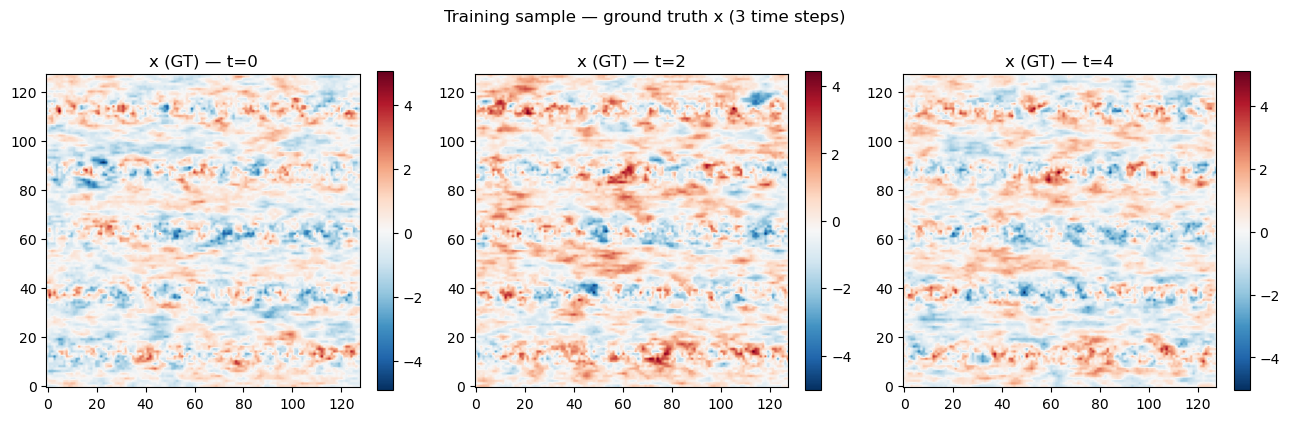

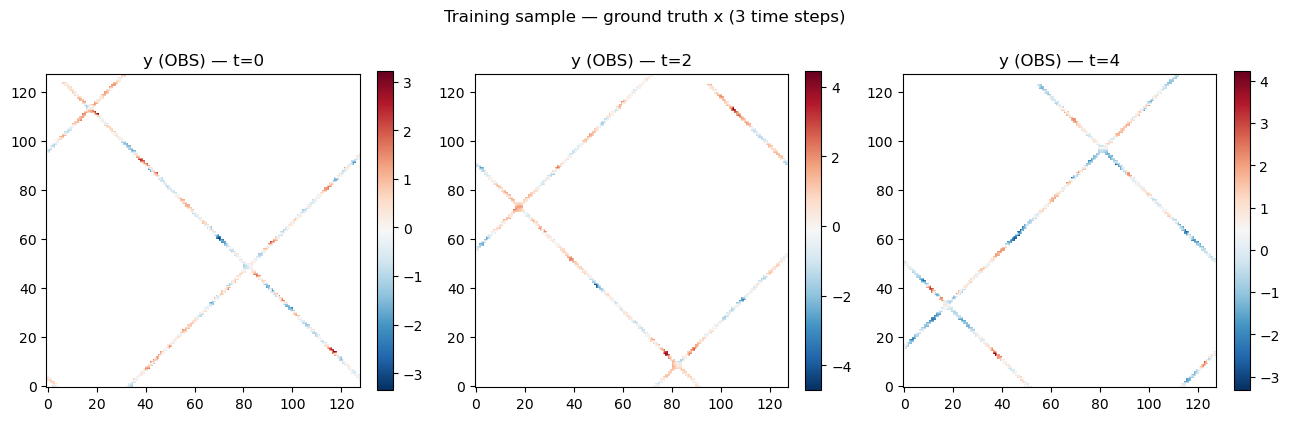

In [9]:
# ---- DataModule ----
# The full dataset is T=15, H=100, W=100.
# window_size=15 → each sample is the full temporal extent.
# stride=1 → only one window (size 1 dataset); use smaller window_size
# to create more samples if needed (e.g. window_size=5, stride=1 → 11 windows).

datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,          # full temporal extent per sample
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

# ---- Sanity plot — first training sample (ground truth x) ----
sample = datamodule.train_ds[0]
print(f"TrainingItem shapes — input (y): {sample.input.shape}, tgt (x): {sample.tgt.shape}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for t_idx, ax in zip([0, 2, 4], axes):
    im = ax.imshow(sample.tgt[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"x (GT) — t={t_idx}")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Training sample — ground truth x (3 time steps)", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for t_idx, ax in zip([0, 2, 4], axes):
    im = ax.imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"y (OBS) — t={t_idx}")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Training sample — ground truth x (3 time steps)", y=1.02)
plt.tight_layout()
plt.show()



### UNet Modules (dataset-agnostic — copied from reference notebook)

In [10]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 noise_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.noise_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(noise_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, cond: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.noise_level_projection(cond)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 noise_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, noise_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, cond: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, cond))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )
    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )
    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


### Sinusoidal Time Embedding

Solver step $t_k = k/(N-1) \in [0,1]$ → conditioning vector `(B, D, 1, 1)` injected into each UNetBlock.


In [11]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int = 128, out_dim: Optional[int] = None) -> None:
        super().__init__()
        out_dim = out_dim or dim
        half = dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, dtype=torch.float32) / (half - 1)
        )
        self.register_buffer("freqs", freqs)
        self.mlp = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            nn.SiLU(),
            nn.Linear(4 * dim, out_dim),
        )

    def forward(self, t: Tensor) -> Tensor:
        if t.dim() == 0:
            t = t.unsqueeze(0)
        t = t.float()
        angles = t[:, None] * self.freqs[None, :]
        emb = torch.cat([angles.sin(), angles.cos()], dim=-1)
        emb = emb.to(dtype=next(self.mlp.parameters()).dtype)
        emb = self.mlp(emb)
        return emb[:, :, None, None]


### UNet Gradient Model

`GradSolverUNetConfig.channels` is set to the **number of time steps per patch** (= `window_size` = 15).


In [12]:
@dataclass
class GradSolverUNetConfig:
    channels: int = 5                                     # C = window_size (time steps per patch)
    time_emb_dim: int = 128
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (56, 56)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (128, 256)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    """Pad H and W to the nearest multiple of `multiple` using reflection padding."""
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    # F.pad: (left, right, top, bottom)
    padding = (0, pad_w, 0, pad_h)
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    """Remove the padding added by _pad_to_multiple."""
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]


class GradSolverUNet(nn.Module):
    def __init__(self, config: GradSolverUNetConfig) -> None:
        super().__init__()
        self.config = config
        C   = config.channels
        D   = config.top_blocks_channels[0]
        EMB = config.time_emb_dim

        self.time_embedding    = SinusoidalTimeEmbedding(dim=EMB, out_dim=EMB)
        self.input_projection  = nn.Conv2d(2 * C, D, kernel_size=3, padding="same")

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block)
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block)
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block)
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block)

        self.output_projection = nn.Conv2d(D, C, kernel_size=3, padding="same")

    def forward(self, x: Tensor, grad_j: Tensor, t: Tensor) -> Tensor:
        grad_norm = (grad_j ** 2).mean().sqrt().clamp(min=1e-8)
        grad_j_n  = grad_j / grad_norm

        # Pad both inputs to a multiple of 8 so Downsample never gets odd dims
        inp = torch.cat([x, grad_j_n], dim=1)
        inp, padding = _pad_to_multiple(inp, multiple=8)

        h    = self.input_projection(inp)
        cond = self.time_embedding(t)

        top_skips = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, cond); top_skips.append(h)
            else:
                h = block(h)

        mid_skips = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, cond); mid_skips.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_skips.pop()), dim=1); h = block(h, cond)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_skips.pop()), dim=1); h = block(h, cond)
            else:
                h = block(h)

        out = self.output_projection(h)
        return _unpad(out, padding)   # restore original H×W

    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx])); ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx])); oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, self.config.time_emb_dim, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(ic, oc, self.config.time_emb_dim, self.config.n_heads, dropout)

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config_4dvarnet_unet.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model_4dvarnet_unet.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "GradSolverUNet":
        with open(os.path.join(pretrained_path, "config_4dvarnet_unet.json"), mode="r") as f:
            config_dict = json.load(f)
        model = cls(GradSolverUNetConfig(**config_dict))
        model.load_state_dict(torch.load(
            os.path.join(pretrained_path, "model_4dvarnet_unet.pt"), map_location="cpu"))
        return model


# Sanity check — 100×100 will be padded to 104×104 internally
C = datamodule.window_size
summary(
    GradSolverUNet(GradSolverUNetConfig(channels=C)),
    input_data=[
        torch.zeros(1, C, 100, 100),
        torch.zeros(1, C, 100, 100),
        torch.tensor([0.5]),
    ],
)


Layer (type:depth-idx)                        Output Shape              Param #
GradSolverUNet                                [1, 5, 100, 100]          --
├─Conv2d: 1-1                                 [1, 56, 104, 104]         5,096
├─SinusoidalTimeEmbedding: 1-2                [1, 128, 1, 1]            --
│    └─Sequential: 2-1                        [1, 128]                  --
│    │    └─Linear: 3-1                       [1, 512]                  66,048
│    │    └─SiLU: 3-2                         [1, 512]                  --
│    │    └─Linear: 3-3                       [1, 128]                  65,664
├─ModuleList: 1-3                             --                        --
│    └─UNetBlock: 2-2                         [1, 56, 104, 104]         --
│    │    └─Sequential: 3-4                   [1, 56, 104, 104]         28,392
│    │    └─Sequential: 3-5                   [1, 56, 1, 1]             7,224
│    │    └─Sequential: 3-6                   [1, 56, 104, 104]         28,39

### Observation Operator & Variational Cost

$J(x) = \|m \odot (x - y)\|^2 + \alpha\,\|x - \text{AE}(x)\|^2$

Mask derived from finite values: `mask = y.isfinite()`, `y_filled = y.nan_to_num(0.0)`.


In [13]:
class ObsCost(nn.Module):
    def __init__(self, w: float = 1.0) -> None:
        super().__init__()
        self.w = w

    def forward(self, state: Tensor, y_filled: Tensor, mask: Tensor) -> Tensor:
        return self.w * F.mse_loss(state * mask, y_filled * mask)


class BilinAEPriorCost(nn.Module):
    def __init__(self, dim_in: int, dim_hidden: int,
                 kernel_size: int = 3, downsamp: Optional[int] = None,
                 bilin_quad: bool = True) -> None:
        super().__init__()
        self.bilin_quad = bilin_quad
        self.conv_in     = nn.Conv2d(dim_in, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.conv_hidden = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.bilin_1     = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.bilin_21    = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.bilin_22    = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.conv_out    = nn.Conv2d(2 * dim_hidden, dim_in, kernel_size, padding=kernel_size // 2)
        self.down = nn.AvgPool2d(downsamp) if downsamp else nn.Identity()
        self.up   = nn.UpsamplingBilinear2d(scale_factor=downsamp) if downsamp else nn.Identity()

    def forward_ae(self, x: Tensor) -> Tensor:
        x = self.down(x)
        x = self.conv_hidden(F.relu(self.conv_in(x)))
        nonlin = self.bilin_21(x) ** 2 if self.bilin_quad else self.bilin_21(x) * self.bilin_22(x)
        x = self.conv_out(torch.cat([self.bilin_1(x), nonlin], dim=1))
        return self.up(x)

    def forward(self, state: Tensor) -> Tensor:
        return F.mse_loss(state, self.forward_ae(state))


def compute_grad_j(state, y_filled, mask, obs_cost, prior_cost, alpha=1.0):
    x = state.requires_grad_(True)
    J = obs_cost(x, y_filled, mask) + alpha * prior_cost(x)
    return torch.autograd.grad(J, x, create_graph=True)[0]


### 4DVarNet Solver

$x_{k+1} = x_k - \text{UNet}(x_k,\; \nabla_x J(x_k),\; t_k)$,  with $x_0 = y_\text{filled}$


In [14]:
class Solver4DVarUNet(nn.Module):
    def __init__(self, grad_model, obs_cost, prior_cost,
                 n_solver: int = 15, alpha_prior: float = 0.2) -> None:
        super().__init__()
        self.grad_model  = grad_model
        self.obs_cost    = obs_cost
        self.prior_cost  = prior_cost
        self.n_solver    = n_solver
        self.alpha_prior = alpha_prior

    def forward(self, y_filled: Tensor, mask: Tensor,
                return_all_iterates: bool = False) -> Union[Tensor, List[Tensor]]:
        B, C, H, W = y_filled.shape
        device, dtype = y_filled.device, y_filled.dtype
        x = y_filled.clone()
        iterates = [x] if return_all_iterates else None

        with torch.set_grad_enabled(True):
            for k in range(self.n_solver):
                t_k = torch.full((B,), k / max(self.n_solver - 1, 1), device=device, dtype=dtype)
                grad_j = compute_grad_j(x, y_filled, mask, self.obs_cost, self.prior_cost, self.alpha_prior)
                dx = self.grad_model(x, grad_j, t_k)
                x  = x - dx
                if not self.training:
                    x = x.detach().requires_grad_(True)
                if return_all_iterates:
                    iterates.append(x)

        return iterates if return_all_iterates else x


### ConvLSTM Gradient Model & Solver (alternative to UNet)

`ConvLstmGradModel` maintains a hidden/cell state across solver iterations — it takes only $\nabla_x J$ as input (no $x$ or $t_k$).

The update rule follows the original 4DVarNet formulation:

$$x_{k+1} = x_k - \left[\frac{1}{k+1}\,\text{LSTM}(\nabla_x J_k) + \eta\,\frac{k+1}{N}\,\nabla_x J_k\right]$$

where $\eta$ is `lr_grad`.


In [15]:
@dataclass
class Lit4DVarUNetConfig:
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000
    intermediate_supervision: bool = False


class Lit4DVarUNet(pl.LightningModule):
    def __init__(self, solver,
                 config: Lit4DVarUNetConfig = Lit4DVarUNetConfig()) -> None:
        super().__init__()
        self.solver = solver
        self.config = config

    @staticmethod
    def _prepare_inputs(y: Tensor) -> Tuple[Tensor, Tensor]:
        mask     = y.isfinite().to(y.dtype)
        y_filled = y.nan_to_num(0.0)
        return y_filled, mask

    def training_step(self, batch, batch_idx):
        if isinstance(batch, list):
            batch = batch[0]
        y_filled, mask = self._prepare_inputs(batch.input)
        tgt = batch.tgt

        if self.config.intermediate_supervision:
            iterates = self.solver(y_filled, mask, return_all_iterates=True)
            N = len(iterates) - 1
            weights = torch.arange(1, N + 2, dtype=tgt.dtype, device=tgt.device)
            weights = weights / weights.sum()
            loss = sum(w * F.mse_loss(xk, tgt) for xk, w in zip(iterates, weights))
        else:
            loss = F.mse_loss(self.solver(y_filled, mask), tgt)

        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        if isinstance(batch, list):
            batch = batch[0]
        y_filled, mask = self._prepare_inputs(batch.input)
        x_final = self.solver(y_filled, mask)
        loss = F.mse_loss(x_final, batch.tgt)
        self.log_dict({"val_loss": loss, "val_rmse": loss.sqrt()}, prog_bar=True)
        return loss

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.config.lr, betas=self.config.betas)
        sched = torch.optim.lr_scheduler.LinearLR(
            opt, start_factor=self.config.lr_scheduler_start_factor,
            end_factor=1.0, total_iters=self.config.lr_scheduler_iters)
        return [opt], [{"scheduler": sched, "interval": "step"}]


In [16]:
@dataclass
class ConvLstmGradModelConfig:
    channels: int = 5          # C = window_size
    dim_hidden: int = 96
    kernel_size: int = 3
    dropout: float = 0.1
    downsamp: Optional[int] = None


class ConvLstmGradModel(nn.Module):
    """Stateful ConvLSTM gradient model — hidden/cell state persists across solver steps."""

    def __init__(self, config: ConvLstmGradModelConfig) -> None:
        super().__init__()
        self.config = config
        C   = config.channels
        H   = config.dim_hidden
        K   = config.kernel_size
        pad = K // 2

        # Project input grad → hidden space
        self.input_proj = nn.Conv2d(C, H, K, padding=pad)

        # LSTM gates (input + hidden → 4*H)
        self.lstm_gates = nn.Conv2d(2 * H, 4 * H, K, padding=pad)

        self.dropout = nn.Dropout2d(config.dropout)
        self.output_proj = nn.Conv2d(H, C, K, padding=pad)

        # Will hold (h, c) between solver iterations
        self._h: Optional[Tensor] = None
        self._c: Optional[Tensor] = None

        if config.downsamp:
            self.down = nn.AvgPool2d(config.downsamp)
            self.up   = nn.UpsamplingBilinear2d(scale_factor=config.downsamp)
        else:
            self.down = nn.Identity()
            self.up   = nn.Identity()

    def reset_state(self) -> None:
        self._h = None
        self._c = None

    def forward(self, grad_j: Tensor) -> Tensor:
        x = self.down(grad_j)
        B, C, H, W = x.shape
        device, dtype = x.device, x.dtype

        h = self._h if self._h is not None else torch.zeros(B, self.config.dim_hidden, H, W, device=device, dtype=dtype)
        c = self._c if self._c is not None else torch.zeros_like(h)

        inp = self.dropout(F.silu(self.input_proj(x)))
        gates = self.lstm_gates(torch.cat([inp, h], dim=1))
        i_g, f_g, g_g, o_g = gates.chunk(4, dim=1)
        c = torch.sigmoid(f_g) * c + torch.sigmoid(i_g) * torch.tanh(g_g)
        h = torch.sigmoid(o_g) * torch.tanh(c)

        self._h = h
        self._c = c

        out = self.output_proj(h)
        return self.up(out)

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config_lstm.json"), "w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model_lstm.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "ConvLstmGradModel":
        with open(os.path.join(pretrained_path, "config_lstm.json"), "r") as f:
            cfg = json.load(f)
        model = cls(ConvLstmGradModelConfig(**cfg))
        model.load_state_dict(torch.load(
            os.path.join(pretrained_path, "model_lstm.pt"), map_location="cpu"))
        return model


class Solver4DVarLSTM(nn.Module):
    """4DVarNet solver using a stateful ConvLSTM gradient model."""

    def __init__(self, grad_model: ConvLstmGradModel, obs_cost, prior_cost,
                 n_solver: int = 15, lr_grad: float = 1e-3, alpha_prior: float = 0.2) -> None:
        super().__init__()
        self.grad_model  = grad_model
        self.obs_cost    = obs_cost
        self.prior_cost  = prior_cost
        self.n_solver    = n_solver
        self.lr_grad     = lr_grad
        self.alpha_prior = alpha_prior

    def forward(self, y_filled: Tensor, mask: Tensor,
                return_all_iterates: bool = False) -> Union[Tensor, List[Tensor]]:
        x = y_filled.clone()
        self.grad_model.reset_state()
        iterates = [x] if return_all_iterates else None

        with torch.set_grad_enabled(True):
            for k in range(self.n_solver):
                grad_j = compute_grad_j(x, y_filled, mask, self.obs_cost, self.prior_cost, self.alpha_prior)
                lstm_out = self.grad_model(grad_j)
                # Update rule: x_{k+1} = x_k - [1/(k+1) * LSTM(∇J) + η*(k+1)/N * ∇J]
                x = x - (lstm_out / (k + 1) + self.lr_grad * (k + 1) / self.n_solver * grad_j)
                if not self.training:
                    x = x.detach().requires_grad_(True)
                if return_all_iterates:
                    iterates.append(x)

        return iterates if return_all_iterates else x


## 🚀 Training

In [17]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last_ckpt = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last_ckpt) and is_valid_checkpoint(last_ckpt):
        print(f"lid checkpoint: {last_ckpt}")
        return last_ckpt
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
         if "last" not in os.path.basename(p)],
        key=lambda p: float(p.split("val_loss=")[-1].replace(".ckpt", ""))
        if "val_loss=" in p else float("inf"),
    )
    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f"Valid checkpoint: {ckpt_path}")
            return ckpt_path
    print("No valid checkpoint found. Starting from scratch.")
    return None

C = datamodule.window_size   # time steps per patch

LOG_DIR     = f"logs_4dvarnet_{SOLVER_TYPE}_spde"
CKPT_DIR    = os.path.join(LOG_DIR, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, "best_model")
# RESET_TRAINING set by the parameters cell above
if RESET_TRAINING:
    import shutil
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
    resume_ckpt = None
    print("RESET_TRAINING=True -- starting from scratch")
else:
    resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

obs_cost   = ObsCost(w=1.0)
prior_cost = BilinAEPriorCost(dim_in=C, dim_hidden=64, bilin_quad=False, downsamp=2)

if SOLVER_TYPE == "unet":
    grad_model = GradSolverUNet(GradSolverUNetConfig(channels=C))
    solver = Solver4DVarUNet(grad_model, obs_cost, prior_cost, n_solver=15, alpha_prior=0.2)
    print("▶ Using UNet gradient model")
else:  # "lstm"
    grad_model = ConvLstmGradModel(ConvLstmGradModelConfig(channels=C, dim_hidden=96))
    solver = Solver4DVarLSTM(grad_model, obs_cost, prior_cost,
                              n_solver=15, lr_grad=1e-3, alpha_prior=0.2)
    print("▶ Using ConvLSTM gradient model")

lit = Lit4DVarUNet(solver, Lit4DVarUNetConfig(lr_scheduler_iters=500, intermediate_supervision=True))

trainer = Trainer(enable_progress_bar=False, 
    accelerator="gpu",
    max_epochs=MAX_EPOCHS,
    accumulate_grad_batches=4,
    precision="16-mixed",
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=""),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="val_loss",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{val_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.callbacks.append(EpochHeartbeat(every_n_epochs=1))
trainer.fit(lit, datamodule, ckpt_path=resume_ckpt)

grad_model.save_pretrained(MODEL_PATH)
print(f"del saved to: {MODEL_PATH}")


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /Odyssey/private/m19beauc/conda_envs/4dvarnet-starte ...
  rank_zero_warn(
Using 16bit Automatic Mixed Precision (AMP)


lid checkpoint: logs_4dvarnet_lstm_spde/checkpoints/last.ckpt
▶ Using ConvLSTM gradient model


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


IPU available: False, using: 0 IPUs


...

[progress] epoch 1998/2000 | train_loss=0.6540 | val_loss=0.8777 | val_rmse=0.9366


[progress] epoch 1999/2000 | train_loss=0.6686 | val_loss=0.8775 | val_rmse=0.9366


[progress] epoch 2000/2000 | train_loss=0.7497 | val_loss=0.8758 | val_rmse=0.9357


`Trainer.fit` stopped: `max_epochs=2000` reached.


del saved to: logs_4dvarnet_lstm_spde/best_model


## 🔍 Evaluation & Visualization

### Load checkpoint


In [18]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

C = datamodule.window_size

obs_cost = ObsCost(w=1.0).to(device=device, dtype=dtype)

# Reload prior_cost with its *trained* weights (learned jointly with grad_model)
prior_cost = BilinAEPriorCost(dim_in=C, dim_hidden=64, bilin_quad=False, downsamp=2)
prior_cost.load_state_dict(torch.load(os.path.join(MODEL_PATH, "prior_cost.pt"), map_location="cpu"))
prior_cost = prior_cost.eval().to(device=device, dtype=dtype)
print("▶ Loaded prior_cost weights from:", MODEL_PATH)

if SOLVER_TYPE == "unet":
    grad_model = GradSolverUNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
    solver = Solver4DVarUNet(
        grad_model=grad_model, obs_cost=obs_cost, prior_cost=prior_cost,
        n_solver=15, alpha_prior=0.2,
    ).eval().to(device=device, dtype=dtype)
    print("▶ Loaded UNet gradient model from:", MODEL_PATH)
else:  # "lstm"
    grad_model = ConvLstmGradModel.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
    solver = Solver4DVarLSTM(
        grad_model=grad_model, obs_cost=obs_cost, prior_cost=prior_cost,
        n_solver=15, lr_grad=1e-3, alpha_prior=0.2,
    ).eval().to(device=device, dtype=dtype)
    print("▶ Loaded ConvLSTM gradient model from:", MODEL_PATH)


▶ Loaded prior_cost weights from: logs_4dvarnet_lstm_spde/best_model
▶ Loaded ConvLSTM gradient model from: logs_4dvarnet_lstm_spde/best_model


### Inference on test batch

In [19]:
# ---- Test batch ----
seed_everything(42)
batch  = next(iter(datamodule.test_dataloader()))
y      = batch.input.to(device=device, dtype=dtype)
x_true = batch.tgt  .to(device=device, dtype=dtype)

mask     = y.isfinite().to(dtype)
y_filled = y.nan_to_num(0.0)

with torch.no_grad():
    iterates = solver(y_filled, mask, return_all_iterates=True)

b = 0
x_hat = iterates[-1].detach()

# ---- OI baseline (same time window as test sample) ----
m_norm, s_norm = datamodule.norm_stats()
start_t = datamodule.test_ds.indices[0]
ws      = datamodule.window_size
oi_np   = datamodule.oi[start_t : start_t + ws].astype(np.float32)   # physical units
oi_norm = (oi_np - m_norm) / s_norm                                    # normalised

rmse    = (x_hat - x_true).pow(2).mean().sqrt().item()
rmse_oi = np.sqrt(np.nanmean((oi_norm - x_true[b].float().cpu().numpy()) ** 2))
print(f"RMSE 4DVarNet (final iterate vs x_true): {rmse:.4f}")
print(f"RMSE OI       (vs x_true, normalised)  : {rmse_oi:.4f}")


m_norm, s_norm = datamodule.norm_stats()
start_t = datamodule.test_ds.indices[0]
_b = 0  # batch index


[rank: 0] Global seed set to 42


RMSE 4DVarNet (final iterate vs x_true): 0.9414
RMSE OI       (vs x_true, normalised)  : 0.8942


### Publication Figures


  Saved: figures/4DVarNet_spde/4DVarNet_spde_obs.png


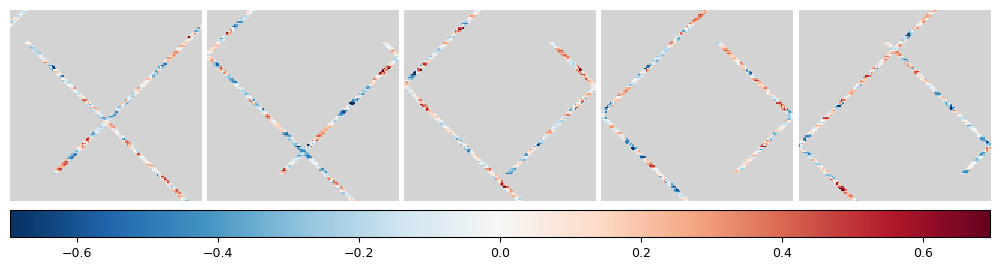

  Saved: figures/4DVarNet_spde/4DVarNet_spde_gt.png


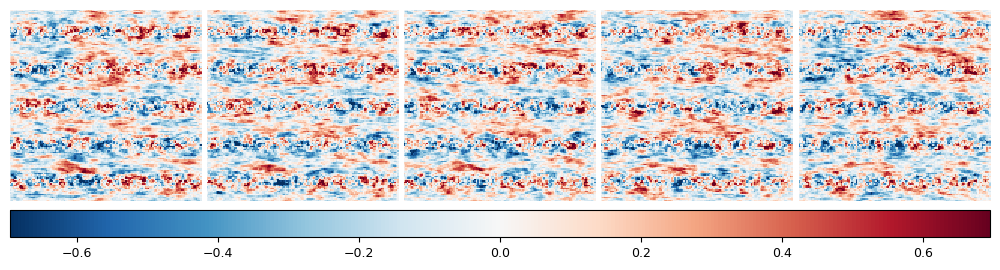

  Saved: figures/4DVarNet_spde/4DVarNet_spde_oi.png


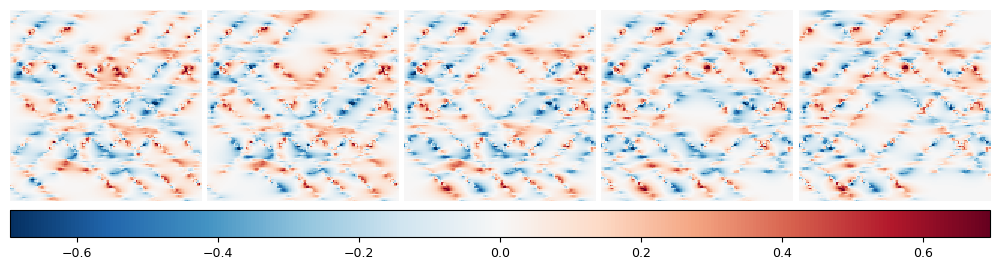

  Saved: figures/4DVarNet_spde/4DVarNet_spde_pred.png


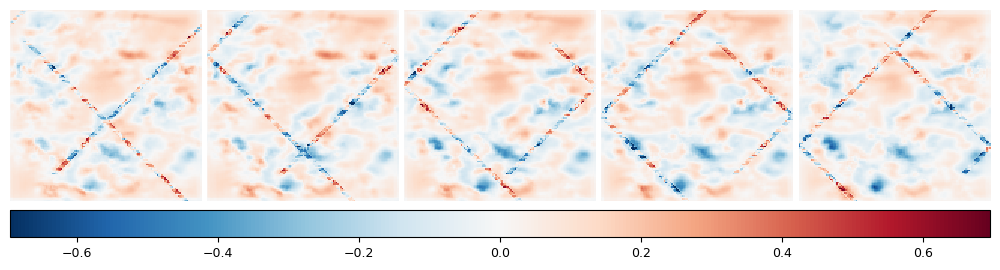

In [20]:
from matplotlib.gridspec import GridSpec

FIG_TAG = '4DVarNet_spde'
FIG_DIR = os.path.join('figures', FIG_TAG)
os.makedirs(FIG_DIR, exist_ok=True)

C = datamodule.window_size
ws = C

obs_phys  = batch.input[_b].float().cpu().numpy() * s_norm + m_norm   # (C,H,W)
gt_phys   = batch.tgt[_b].float().cpu().numpy()   * s_norm + m_norm   # (C,H,W)
oi_phys   = datamodule.oi[start_t: start_t + ws].astype(np.float32)
pred_phys = x_hat[_b].float().cpu().numpy()       * s_norm + m_norm   # (C,H,W)

vmax_f = float(np.nanpercentile(np.abs(gt_phys), 99))
vmin_f = -vmax_f

cmap_f = plt.cm.RdBu_r.copy(); cmap_f.set_bad('lightgray')

def _save_strip(data, filename, vmin, vmax, cmap):
    FW, FH, CB_H = 2.0, 2.0, 0.28
    fig_w = C * FW
    fig_h = FH + CB_H + 0.06
    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = GridSpec(2, C,
                  left=0.01, right=0.99, top=0.99, bottom=0.01,
                  height_ratios=[FH, CB_H], hspace=0.06, wspace=0.03)
    for c in range(C):
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(data[c], origin='lower', cmap=cmap,
                  vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.axis('off')
    ax_cb = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.ax.tick_params(labelsize=9)
    fpath = os.path.join(FIG_DIR, f'{filename}.png')
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    print(f'  Saved: {fpath}')
    plt.show()

figures = [
    (obs_phys,  f'{FIG_TAG}_obs',  vmin_f, vmax_f, cmap_f),
    (gt_phys,   f'{FIG_TAG}_gt',   vmin_f, vmax_f, cmap_f),
    (oi_phys,   f'{FIG_TAG}_oi',   vmin_f, vmax_f, cmap_f),
    (pred_phys, f'{FIG_TAG}_pred', vmin_f, vmax_f, cmap_f),
]

for data, fname, vmin, vmax, cmap in figures:
    _save_strip(data, fname, vmin, vmax, cmap)


## 📊 Metrics — 4DVarNet vs OI

Evaluation at the **centre of the assimilation window** (`t=T_EVAL`, `C=5`).

| Metric | Description |
|---|---|
| **Score ↑** | $1 - \text{RMSE}/\sigma_{\text{GT}}$ |
| **RMSE ↓** | Root Mean Square Error vs GT |
| **σ_pred** | Standard deviation of prediction |
| **λx ↓** | Resolved scale (px): wavelength where spectral score = 0.5 |


Evaluated 225 (test sample, timestep) pairs across the full test set

## Metrics -- full test set (whole domain), n=225 (sample,t) pairs



,Score ↑,RMSE ↓,σ_GT,σ_pred,λx [px]
Method,,,,,
4DVarNet (full test set),0.035 ± 0.016,0.2404 ± 0.0061,0.2492 ± 0.0058,0.1099 ± 0.0061,79.1 ± 61.1
OI baseline (full test set),0.096 ± 0.016,0.2253 ± 0.0040,0.2492 ± 0.0058,0.1578 ± 0.0062,43.1 ± 35.9


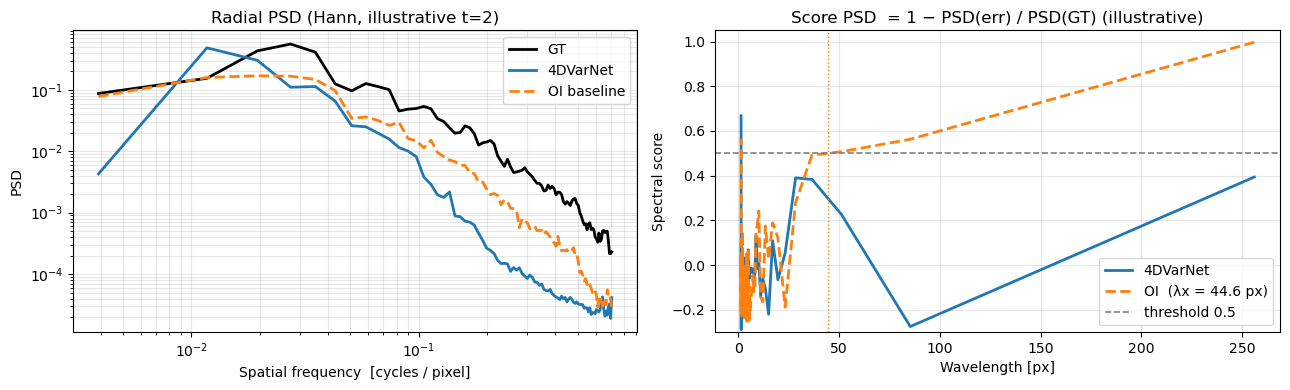

In [21]:
import sys
sys.path.append('../..')   # -> consistency/
from spectral_utils import radial_psd_2d, psd_spectral_score, resolved_scale
import pandas as pd

DX_PX  = 1.0                           # 1 pixel = 1 km (assumption)

# ── Full test-set evaluation ─────────────────────────────────────────────
# Loops over EVERY batch of datamodule.test_dataloader() (not just the first
# one used for the illustrative figures above) and EVERY timestep of the
# assimilation window (not just T_EVAL=window_size//2), comparing against the
# matching OI baseline slice for every (sample, timestep) pair. Deterministic
# method -- one solver pass per batch, no ensemble/CRPS.
_all_4dv = {'score': [], 'rmse': [], 'sigma_gt': [], 'sigma_pred': [], 'lambda_x': []}
_all_oi  = {'score': [], 'rmse': [], 'sigma_gt': [], 'sigma_pred': [], 'lambda_x': []}
_n_pairs = 0
_sample_counter = 0

for _tb in datamodule.test_dataloader():
    _y_b      = _tb.input.to(device=device, dtype=dtype)
    _x_true_b = _tb.tgt.to(device=device, dtype=dtype)
    _Bb, _Cb, _Hb, _Wb = _x_true_b.shape

    _mask_b     = _y_b.isfinite().to(dtype)
    _y_filled_b = _y_b.nan_to_num(0.0)
    with torch.no_grad():
        _iterates_b = solver(_y_filled_b, _mask_b, return_all_iterates=True)
    _x_hat_b = _iterates_b[-1].detach()

    for _bi in range(_Bb):
        _start_t = datamodule.test_ds.indices[_sample_counter]
        _sample_counter += 1
        _oi_traj = datamodule.oi[_start_t : _start_t + _Cb].astype(np.float32)   # (C, H, W)

        for _t in range(_Cb):
            _gt_p   = _x_true_b[_bi, _t].float().cpu().numpy() * s_norm + m_norm
            _pred_p = _x_hat_b[_bi, _t].float().cpu().numpy()  * s_norm + m_norm
            _oi_p   = _oi_traj[_t]

            _sigma = float(np.nanstd(_gt_p))
            if _sigma <= 0:
                continue
            _rmse  = float(np.sqrt(np.nanmean((_pred_p - _gt_p) ** 2)))
            _score = 1.0 - _rmse / _sigma
            _sigma_pred = float(np.nanstd(_pred_p))

            _gt_f   = np.nan_to_num(_gt_p,   nan=0.0)
            _pred_f = np.nan_to_num(_pred_p, nan=0.0)
            _wl, _, _, _spec = psd_spectral_score(_pred_f, _gt_f, dx=DX_PX)
            _lam = resolved_scale(_wl, _spec, threshold=0.5)

            _all_4dv['score'].append(_score)
            _all_4dv['rmse'].append(_rmse)
            _all_4dv['sigma_gt'].append(_sigma)
            _all_4dv['sigma_pred'].append(_sigma_pred)
            _all_4dv['lambda_x'].append(_lam)

            _rmse_oi  = float(np.sqrt(np.nanmean((_oi_p - _gt_p) ** 2)))
            _score_oi = 1.0 - _rmse_oi / _sigma
            _sigma_oi_pred = float(np.nanstd(_oi_p))
            _oi_f = np.nan_to_num(_oi_p, nan=0.0)
            _wl_oi, _, _, _spec_oi = psd_spectral_score(_oi_f, _gt_f, dx=DX_PX)
            _lam_oi = resolved_scale(_wl_oi, _spec_oi, threshold=0.5)
            _all_oi['score'].append(_score_oi)
            _all_oi['rmse'].append(_rmse_oi)
            _all_oi['sigma_gt'].append(_sigma)
            _all_oi['sigma_pred'].append(_sigma_oi_pred)
            _all_oi['lambda_x'].append(_lam_oi)

            _n_pairs += 1

print(f"Evaluated {_n_pairs} (test sample, timestep) pairs across the full test set")

def _agg(vals):
    a = np.asarray(vals, dtype=float)
    a = a[~np.isnan(a)]
    return (float(np.mean(a)), float(np.std(a))) if len(a) else (np.nan, np.nan)

def _row(all_dict, label):
    score_m, score_s = _agg(all_dict['score'])
    rmse_m, rmse_s   = _agg(all_dict['rmse'])
    sgt_m, sgt_s     = _agg(all_dict['sigma_gt'])
    spr_m, spr_s     = _agg(all_dict['sigma_pred'])
    lam_m, lam_s     = _agg(all_dict['lambda_x'])
    return {
        'Method'   : label,
        'Score ↑'  : f'{score_m:.3f} ± {score_s:.3f}',
        'RMSE ↓'   : f'{rmse_m:.4f} ± {rmse_s:.4f}',
        'σ_GT'     : f'{sgt_m:.4f} ± {sgt_s:.4f}',
        'σ_pred'   : f'{spr_m:.4f} ± {spr_s:.4f}',
        'λx [px]'  : f'{lam_m:.1f} ± {lam_s:.1f}' if not np.isnan(lam_m) else '?',
    }

row_4dv = _row(_all_4dv, '4DVarNet (full test set)')
row_oi  = _row(_all_oi,  'OI baseline (full test set)')

df_metrics = pd.DataFrame([row_4dv, row_oi]).set_index('Method')
print(f'\n## Metrics -- full test set (whole domain), n={_n_pairs} (sample,t) pairs\n')
display(df_metrics)

# ── Illustrative PSD plot (single example, T_EVAL=window_size//2 of the first
# test batch, same one used by the figures above) -- qualitative check only,
# NOT the quantitative table (that's df_metrics above, full test set now).
T_EVAL = datamodule.window_size // 2
gt_p_ex   = x_true[_b, T_EVAL].float().cpu().numpy() * s_norm + m_norm
pred_p_ex = x_hat[_b, T_EVAL].float().cpu().numpy()  * s_norm + m_norm
oi_p_ex   = datamodule.oi[start_t + T_EVAL].astype(np.float32)

wl_gt,   psd_gt_sig   = radial_psd_2d(gt_p_ex,   dx=DX_PX)
wl_4dv2, psd_4dv_sig  = radial_psd_2d(pred_p_ex, dx=DX_PX)
wl_oi2,  psd_oi_sig   = radial_psd_2d(oi_p_ex,   dx=DX_PX)
wl_4dv, _, _, spec_4dv = psd_spectral_score(pred_p_ex, gt_p_ex, dx=DX_PX)
wl_oi,  _, _, spec_oi  = psd_spectral_score(oi_p_ex,   gt_p_ex, dx=DX_PX)
lambda_x_4dv = resolved_scale(wl_4dv, spec_4dv)
lambda_x_oi  = resolved_scale(wl_oi,  spec_oi)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for wl, psd, color, ls, lbl in [
    (wl_gt,   psd_gt_sig,   'black', '-',  'GT'),
    (wl_4dv2, psd_4dv_sig,  'C0',   '-',  '4DVarNet'),
    (wl_oi2,  psd_oi_sig,   'C1',   '--', 'OI baseline'),
]:
    v = np.isfinite(wl) & np.isfinite(psd) & (wl > 0) & (psd > 0)
    ax.loglog(1.0/wl[v], psd[v], color=color, ls=ls, lw=2, label=lbl)
ax.set_xlabel('Spatial frequency  [cycles / pixel]')
ax.set_ylabel('PSD')
ax.set_title(f'Radial PSD (Hann, illustrative t={T_EVAL})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
lbl_4dv = f'4DVarNet  (λx = {lambda_x_4dv:.1f} px)' if not np.isnan(lambda_x_4dv) else '4DVarNet'
lbl_oi  = f'OI  (λx = {lambda_x_oi:.1f} px)'         if not np.isnan(lambda_x_oi)  else 'OI'
for wl, spec, color, ls, lbl in [
    (wl_4dv, spec_4dv, 'C0', '-',  lbl_4dv),
    (wl_oi,  spec_oi,  'C1', '--', lbl_oi),
]:
    v = np.isfinite(wl) & np.isfinite(spec)
    ax.plot(wl[v], spec[v], color=color, ls=ls, lw=2, label=lbl)
ax.axhline(0.5, color='gray', lw=1.2, ls='--', label='threshold 0.5')
if not np.isnan(lambda_x_4dv):
    ax.axvline(lambda_x_4dv, color='C0', lw=1, ls=':')
if not np.isnan(lambda_x_oi):
    ax.axvline(lambda_x_oi,  color='C1', lw=1, ls=':')
ax.set_xlabel('Wavelength [px]')
ax.set_ylabel('Spectral score')
ax.set_title('Score PSD  = 1 − PSD(err) / PSD(GT) (illustrative)')
ax.set_ylim(-0.3, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# --- metrics serialization (patch_notebook_params.py) ---
import os
os.makedirs(os.path.dirname(METRICS_CSV) or '.', exist_ok=True)
_df_out = df_metrics.reset_index() if df_metrics.index.name == 'Method' else df_metrics
_df_out.to_csv(METRICS_CSV, index=False)
print(f'Metrics written to {METRICS_CSV}')


Metrics written to /Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/GP/4dvarnet_lstm_metrics_train.csv
